In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import os

In [2]:
PARTICLE_CONFIG = {
    'n_particles': 19,
    'features_per_particle': 3,
    'particle_names': [
        r'$E_\mathrm{T}^\mathrm{miss}$',
        r'$e_0$', r'$e_1$', r'$e_2$', r'$e_3$',
        r'$\mu_0$', r'$\mu_1$', r'$\mu_2$', r'$\mu_3$',
        r'$j_0$', r'$j_1$', r'$j_2$', r'$j_3$', r'$j_4$', r'$j_5$', r'$j_6$', r'$j_7$', r'$j_8$', r'$j_9$'
    ],
    'particle_types': ['MET'] + ['Electron']*4 + ['Muon']*4 + ['Jet']*10,
    'type_colors': {
        'MET': '#e41a1c',      # Red
        'Electron': '#377eb8', # Blue
        'Muon': '#4daf4a',     # Green
        'Jet': '#ff7f00'       # Orange
    }
}
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
})

In [3]:
# Where to save the comparison plots
output_plot_dir = "../output/PaperPlots/"
os.makedirs(output_plot_dir, exist_ok=True)

<Figure size 4000x2400 with 0 Axes>

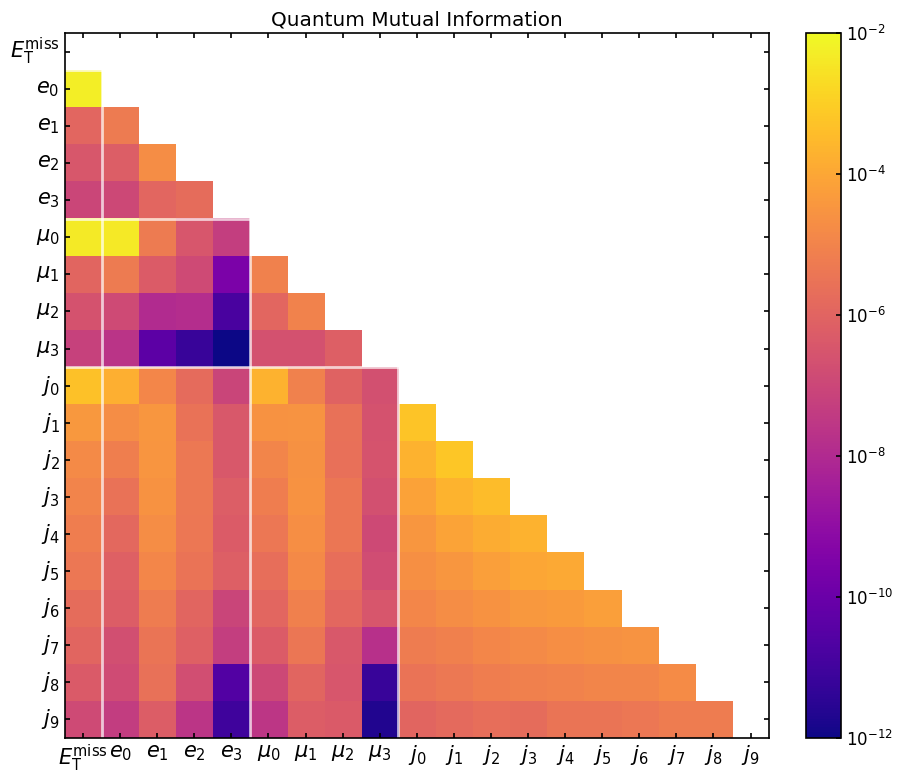

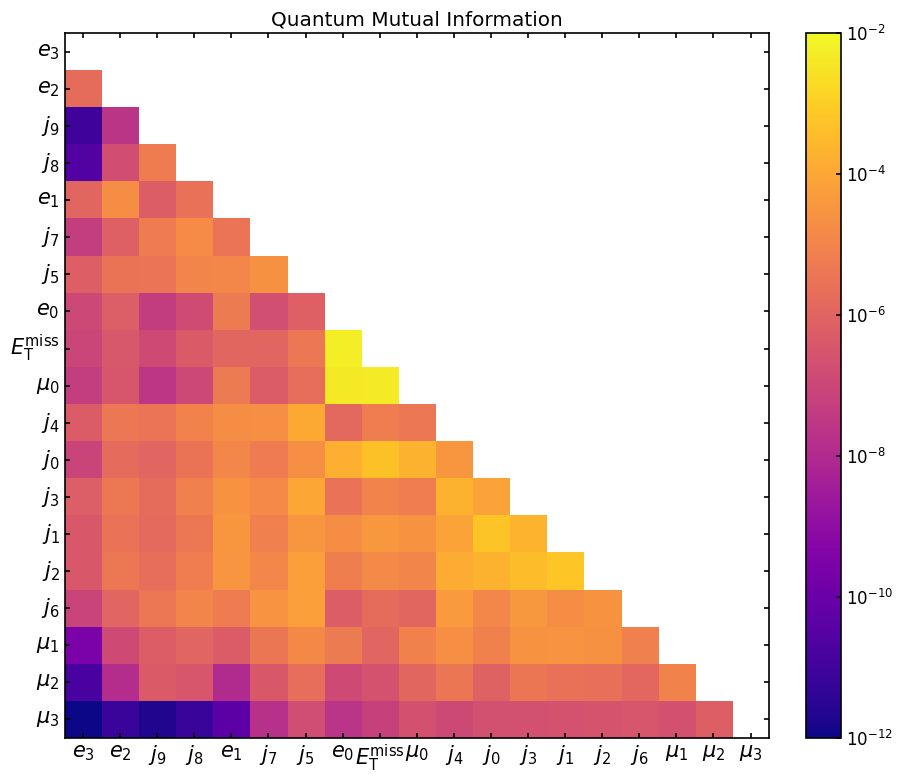

In [4]:
particle_names = PARTICLE_CONFIG['particle_names']
log_scale=True
heatmap = 'plasma'
# Compute normalization parameters (shared between both plots)
qmi_matrix = np.load('qmi_matrix.npy')
ordering = np.load('optimal_ordering.npy')
qmi_off_diag = qmi_matrix.copy()
np.fill_diagonal(qmi_off_diag, np.nan)
vmax = np.nanmax(qmi_off_diag)
positive_vals = qmi_off_diag[qmi_off_diag > 0]
vmin = np.nanmin(positive_vals) if (log_scale and len(positive_vals) > 0) else (1e-10 if log_scale else 0)
## Override min
vmin = 1e-12
vmax = 1e-2
if log_scale:
    norm = LogNorm(vmin=vmin, vmax=vmax)
else:
    norm = Normalize(vmin=0, vmax=vmax)

# Prepare matrices for plotting
def prep_matrix(mat):
    m = mat.copy().astype(float)
    # for i in np.arange(mat.shape[0]):
    #     for j in np.arange(mat.shape[1]):
    #         if (j>=i): m[i][j]=1
    if log_scale:
        m[m <= 0] = vmin
    mask = np.triu(np.ones(m.shape, dtype=bool), k=0)  # k=0 includes diagonal
    m[mask] = np.nan
    return m

plt.figure(figsize=(10,6), dpi=400)
# Original ordering
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(prep_matrix(qmi_matrix), cmap=heatmap, aspect='equal', norm=norm)
ax.set_xticks(np.arange(len(particle_names)))
ax.set_yticks(np.arange(len(particle_names)))
ax.set_xticklabels(particle_names, ha='center', fontsize=15)
ax.set_yticklabels(particle_names, va='center', fontsize=15)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Add type boundaries
for b in [0.5, 4.5, 8.5]:
    ax.axhline(y=b, color='white', linewidth=2, alpha=0.7)
    ax.axvline(x=b, color='white', linewidth=2, alpha=0.7)
plt.title('Quantum Mutual Information')
plt.savefig(output_plot_dir+'qmi_normal.pdf', dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Reordered
fig, ax = plt.subplots(figsize=(10,8))
qmi_reordered = qmi_matrix[np.ix_(ordering, ordering)]
names_reordered = [particle_names[i] for i in ordering]

im = ax.imshow(prep_matrix(qmi_reordered), cmap=heatmap, aspect='equal', norm=norm)
ax.set_xticks(np.arange(len(particle_names)))
ax.set_yticks(np.arange(len(particle_names)))
ax.set_xticklabels(names_reordered, ha='center', fontsize=15)
ax.set_yticklabels(names_reordered, va='center', fontsize=15)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.title('Quantum Mutual Information')
plt.tight_layout()
plt.savefig(output_plot_dir+'qmi_spectral.pdf', dpi=200, bbox_inches='tight')
plt.show()